# Scatter Plot Gallery

Scatter plots show the relationship between two numeric variables, one observation per point. They're the chart of choice when the question is "are these two things correlated" or "which observations are outliers". Adding colour by group reveals whether the relationship differs across categories, and adding bubble sizing folds in a third dimension without crowding the chart.

Scatter plots excel at:
- **Relationship analysis**: see whether two variables move together, against each other, or independently
- **Group comparison**: contrast the shape of a relationship across product categories or store formats
- **Outlier identification**: spot the SKU, store, or customer that sits well off the cluster
- **Bubble charts**: encode a third variable as point size for richer comparison without a second chart

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from openretailscience.plots import scatter
from openretailscience.plots.styles.graph_utils import set_axis_shorthand

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Numbers are picked so the chart's headline holds at a glance — no random noise.

# Eight SKUs across one category. Units fall monotonically as price climbs.
sku_price_volume = pd.DataFrame(
    {
        "price": [25, 40, 60, 75, 95, 120, 150, 200],
        "units_sold": [950, 720, 480, 380, 280, 210, 140, 90],
    },
)

# Per-category SKU panel. Slopes are hand-tuned so Electronics is the steepest
# decliner (most price-elastic) and Home is the flattest (least elastic).
category_sku_panel = pd.DataFrame(
    [
        # Electronics — high price elasticity
        {"category": "Electronics", "price": 40, "units_sold": 1900},
        {"category": "Electronics", "price": 55, "units_sold": 1450},
        {"category": "Electronics", "price": 70, "units_sold": 1100},
        {"category": "Electronics", "price": 85, "units_sold": 820},
        {"category": "Electronics", "price": 95, "units_sold": 670},
        {"category": "Electronics", "price": 105, "units_sold": 540},
        {"category": "Electronics", "price": 115, "units_sold": 440},
        {"category": "Electronics", "price": 120, "units_sold": 400},
        # Apparel — moderate elasticity
        {"category": "Apparel", "price": 20, "units_sold": 1500},
        {"category": "Apparel", "price": 30, "units_sold": 1280},
        {"category": "Apparel", "price": 40, "units_sold": 1090},
        {"category": "Apparel", "price": 50, "units_sold": 940},
        {"category": "Apparel", "price": 60, "units_sold": 810},
        {"category": "Apparel", "price": 70, "units_sold": 700},
        {"category": "Apparel", "price": 75, "units_sold": 650},
        {"category": "Apparel", "price": 80, "units_sold": 610},
        # Home — gentle elasticity
        {"category": "Home", "price": 30, "units_sold": 1000},
        {"category": "Home", "price": 45, "units_sold": 920},
        {"category": "Home", "price": 55, "units_sold": 870},
        {"category": "Home", "price": 70, "units_sold": 800},
        {"category": "Home", "price": 80, "units_sold": 750},
        {"category": "Home", "price": 90, "units_sold": 710},
        {"category": "Home", "price": 95, "units_sold": 680},
        {"category": "Home", "price": 100, "units_sold": 650},
    ],
)

# Monthly store totals. Revenue and profit move in lockstep at very different scales.
store_monthly = pd.DataFrame(
    {
        "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
        "revenue": [125_000, 135_000, 142_000, 138_000, 155_000, 148_000],
        "profit": [15_000, 18_000, 21_000, 19_000, 24_000, 22_000],
    },
)

# Six stores: high-AOV stores see fewer daily visits but earn more revenue per day.
store_economics = pd.DataFrame(
    {
        "store": ["Camden", "Brixton", "Shoreditch", "Clapham", "Islington", "Notting Hill"],
        "avg_order_value": [45, 62, 38, 75, 52, 88],
        "avg_daily_visits": [850, 620, 1100, 480, 720, 380],
        "avg_daily_revenue": [1200, 1800, 800, 2400, 1500, 2800],
    },
)

# Six products spanning a wide price range with broadly similar satisfaction ratings.
product_satisfaction = pd.DataFrame(
    {
        "product_name": [
            "MacBook Air",
            "Logitech M185",
            "Logitech K380",
            "Dell P2422H",
            "Sony WH-CH520",
            "iPad 10th gen",
        ],
        "price": [899, 25, 75, 299, 149, 399],
        "satisfaction": [4.5, 4.2, 4.0, 4.3, 4.1, 4.4],
    },
)

## Basic Scatter Plot

The simplest call: pick an `x_col` and a `value_col`, one point per row. Use this shape when each row is an independent observation (a SKU, a store, a transaction) and you want to see how the two variables relate. With no grouping or sizing, the dots all share one colour and one size.

---

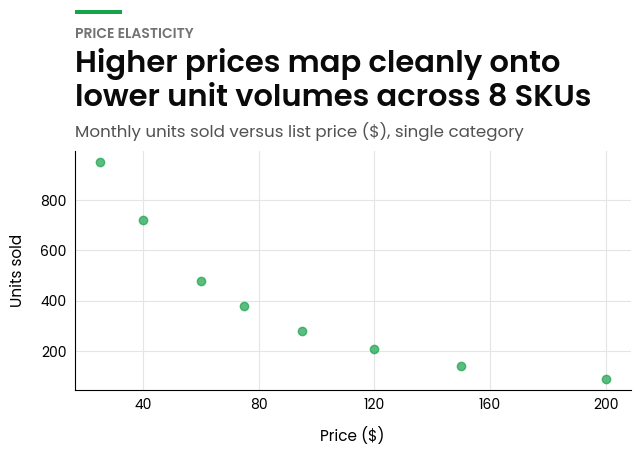

In [ ]:
scatter.plot(
    sku_price_volume,
    x_col="price",
    value_col="units_sold",
    eyebrow="Price elasticity",
    title="Higher prices map cleanly onto lower unit volumes across 8 SKUs",
    subtitle="Monthly units sold versus list price ($), single category",
    x_label="Price ($)",
    y_label="Units sold",
)
plt.show()

## Multiple Scatter Groups

Pass `group_col` to colour each point by a category, drawing the groups as overlaid scatter clouds. Pick this when the analytical question is whether the relationship between the two axes *differs* across groups, not just whether it exists overall. Each group's slope, intercept, and spread become visible at a glance.

---

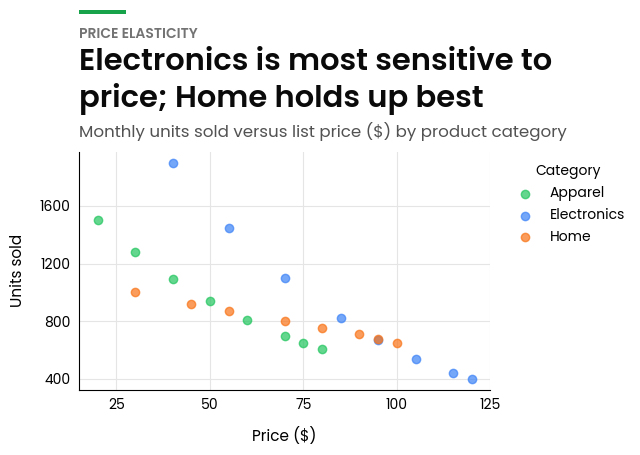

In [ ]:
scatter.plot(
    category_sku_panel,
    x_col="price",
    value_col="units_sold",
    group_col="category",
    eyebrow="Price elasticity",
    title="Electronics is most sensitive to price; Home holds up best",
    subtitle="Monthly units sold versus list price ($) by product category",
    x_label="Price ($)",
    y_label="Units sold",
    legend_title="Category",
    move_legend_outside=True,
)
plt.show()

## Multiple Value Columns

If the data is already in *wide format* with several metrics per x-value, pass a list to `value_col` to overlay them on a shared axis. The two are mutually exclusive with `group_col`: passing both raises `ValueError`. As with line charts, the shared y-axis can squash smaller series, which is often the point of the chart (showing how disparate the magnitudes are).

---

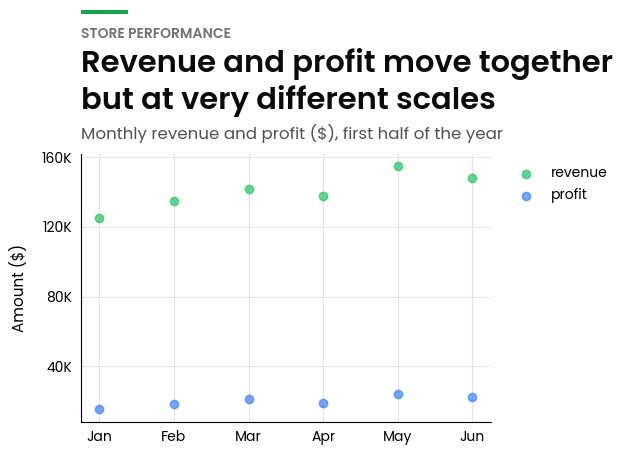

In [ ]:
ax = scatter.plot(
    store_monthly,
    x_col="month",
    value_col=["revenue", "profit"],
    eyebrow="Store performance",
    title="Revenue and profit move together but at very different scales",
    subtitle="Monthly revenue and profit ($), first half of the year",
    y_label="Amount ($)",
    move_legend_outside=True,
)
set_axis_shorthand(ax.yaxis)
plt.show()

## Bubble Chart with `size_col`

Pass `size_col` to encode a third numeric variable as point area, turning the scatter into a bubble chart. Use `size_scale` to multiply the raw values up or down until the bubbles are visually balanced (large enough to compare, small enough to avoid overlap).

---

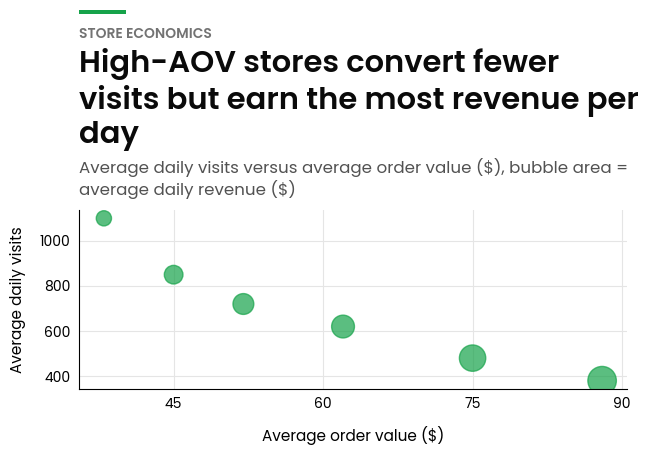

In [ ]:
scatter.plot(
    store_economics,
    x_col="avg_order_value",
    value_col="avg_daily_visits",
    size_col="avg_daily_revenue",
    size_scale=0.15,
    eyebrow="Store economics",
    title="High-AOV stores convert fewer visits but earn the most revenue per day",
    subtitle="Average daily visits versus average order value (\\$), bubble area = average daily revenue (\\$)",
    x_label="Average order value ($)",
    y_label="Average daily visits",
)
plt.show()

## Point Labels with `label_col`

Pass `label_col` to write each point's name next to it, using `textalloc` to nudge labels apart so they don't overlap. Use this for small datasets (under ~20 points) where the reader needs to identify each observation, like a product comparison or a regional benchmark. Note: `label_col` is mutually exclusive with a list-typed `value_col` — labels only make sense when there's one value per point.

---

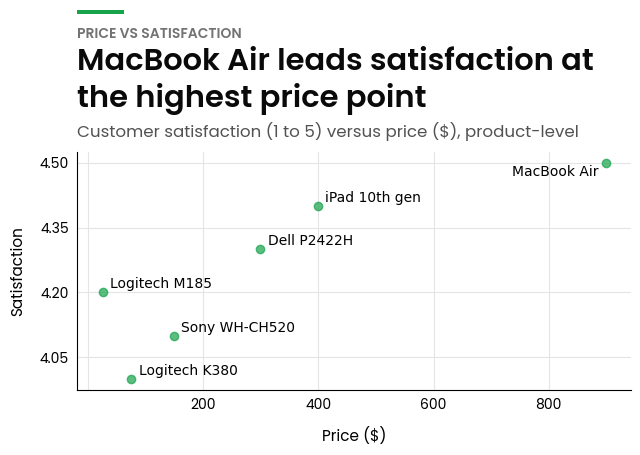

In [ ]:
scatter.plot(
    product_satisfaction,
    x_col="price",
    value_col="satisfaction",
    label_col="product_name",
    eyebrow="Price vs satisfaction",
    title="MacBook Air leads satisfaction at the highest price point",
    subtitle="Customer satisfaction (1 to 5) versus price ($), product-level",
    x_label="Price ($)",
    y_label="Satisfaction",
)
plt.show()